
--- Error Results (Experimental vs Simulation) ---
Case              MAE       RMSE
0.375          0.2058     0.2344
0.95           0.1622     0.1889
1.53           0.0935     0.1107
3.75           0.2443     0.2691
9.4            0.0366     0.0425


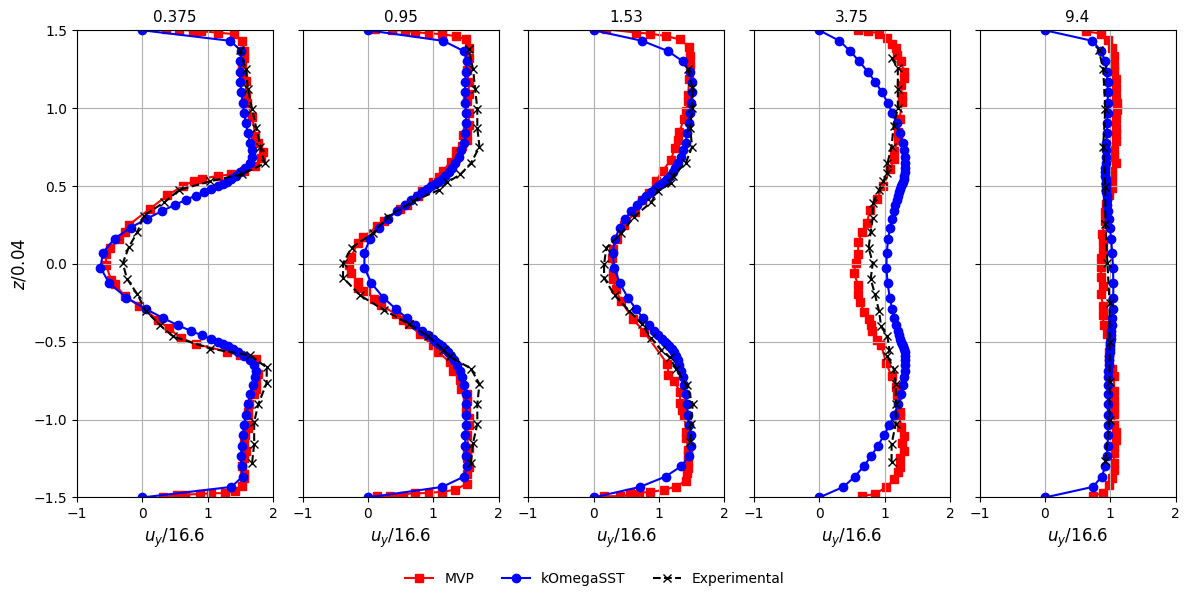

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# === Case setup ===
case_ids = ['0p375', '0p95', '1p53', '3p75', '9p4']
case_titles = ['0.375', '0.95', '1.53', '3.75', '9.4']
bk_keys = ['bk0_375', 'bk0_95', 'bk1_53', 'bk3_75', 'bk9_4']
bb_keys = ['bb0_375', 'bb0_95', 'bb1_53', 'bb3_75', 'bb9_4']

# === Load experimental/MVP dataset ===
df_ref = pd.read_csv('/home/d/Downloads/all_black_blue_data.csv')

# === Create subplots: 1 row, 5 columns ===
fig, axes = plt.subplots(1, 5, figsize=(12, 6), sharey=True)

for i, case in enumerate(case_ids):
    ax = axes[i]

    # --- kOmegaSST simulation ---
    sim_file = f'/home/d/ssh_files/transient2_kOmegaSST_2/{case}.csv'
    df_sim = pd.read_csv(sim_file)
    df_sim = df_sim[['Points:2', 'U_average:1']]
    df_avg = df_sim.groupby('Points:2', as_index=False)['U_average:1'].mean()
    z_norm = df_avg['Points:2'] / 0.04
    u_norm = df_avg['U_average:1'] / 16.6

    # --- Experimental data ---
    x_bk = df_ref[f'{bk_keys[i]}_x']
    y_bk = df_ref[f'{bk_keys[i]}_y']
    df_bk = pd.DataFrame({'x': x_bk, 'y': y_bk}).dropna().sort_values(by='y')
    x_bk_sorted = df_bk['x']
    y_bk_sorted = df_bk['y']

    # --- MVP data ---
    x_bb = df_ref[f'{bb_keys[i]}_x']
    y_bb = df_ref[f'{bb_keys[i]}_y']
    df_bb = pd.DataFrame({'x': x_bb, 'y': y_bb}).dropna().sort_values(by='y')
    x_bb_sorted = df_bb['x']
    y_bb_sorted = df_bb['y']

    # --- Plot curves ---
    ax.plot(x_bb_sorted, y_bb_sorted, marker='s', linestyle='-', label='MVP', color='red', zorder=1)
    ax.plot(u_norm, z_norm, marker='o', linestyle='-', label='kOmegaSST', color='blue', zorder=2)
    ax.plot(x_bk_sorted, y_bk_sorted, marker='x', linestyle='--', label='Experimental', color='black', zorder=3)

    ax.set_title(f'{case_titles[i]}', fontsize=11)
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks(np.arange(-1, 2.1, 1))
    ax.set_yticks(np.arange(-1.5, 1.6, 0.5))
    ax.grid(True)

    if i == 0:
        ax.set_ylabel(r'$z / 0.04$', fontsize=12)
    ax.set_xlabel(r'$u_{y} / 16.6$', fontsize=12)

# === Add common legend ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig('/home/d/ssh_files/transient2_kOmegaSST_2/fig6a_axial_vel_exp_vs_sim.png', dpi=300)

# === Compute error (Experimental vs Simulation) ===
error_results = []

for i, case in enumerate(case_ids):
    # --- Load simulation ---
    sim_file = f'/home/d/ssh_files/transient2_kOmegaSST_2/{case}.csv'
    df_sim = pd.read_csv(sim_file)
    df_sim = df_sim[['Points:2', 'U_average:1']]
    df_avg = df_sim.groupby('Points:2', as_index=False)['U_average:1'].mean()
    z_norm = df_avg['Points:2'] / 0.04
    u_norm = df_avg['U_average:1'] / 16.6

    # --- Experimental data ---
    x_bk = df_ref[f'{bk_keys[i]}_x']
    y_bk = df_ref[f'{bk_keys[i]}_y']
    df_bk = pd.DataFrame({'x': x_bk, 'y': y_bk}).dropna().sort_values(by='y')
    x_bk_sorted = df_bk['x']
    y_bk_sorted = df_bk['y']

    # --- Interpolate simulation at experimental points ---
    sim_interp = np.interp(y_bk_sorted, z_norm, u_norm)

    # --- Calculate errors ---
    mae = mean_absolute_error(x_bk_sorted, sim_interp)
    rmse = np.sqrt(mean_squared_error(x_bk_sorted, sim_interp))

    error_results.append((case_titles[i], mae, rmse))  # use formatted titles here

# === Print error results ===
print("\n--- Error Results (Experimental vs Simulation) ---")
print(f"{'Case':<10} {'MAE':>10} {'RMSE':>10}")
for case, mae, rmse in error_results:
    print(f"{case:<10} {mae:10.4f} {rmse:10.4f}")

plt.show()


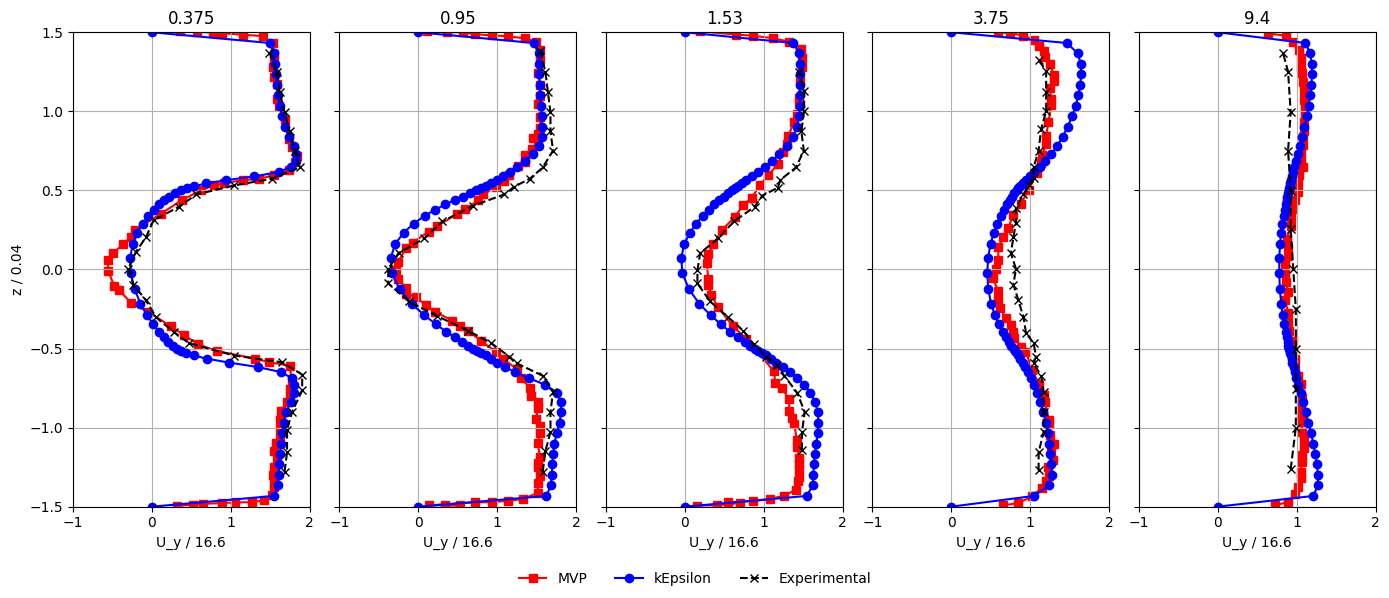


--- Error Results (kEpsilon vs Experimental) ---
Case              MAE       RMSE
0.375          0.1614     0.2357
0.95           0.1953     0.2343
1.53           0.2207     0.2734
3.75           0.2295     0.2642
9.4            0.1777     0.2045


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# === Case setup ===
case_ids = ['0p375', '0p95', '1p53', '3p75', '9p4']                      # For filenames
case_titles = ['0.375', '0.95', '1.53', '3.75', '9.4']                   # For subplot titles
bk_keys = ['bk0_375', 'bk0_95', 'bk1_53', 'bk3_75', 'bk9_4']             # Experimental
bb_keys = ['bb0_375', 'bb0_95', 'bb1_53', 'bb3_75', 'bb9_4']             # MVP

# === Load reference dataset ===
df_ref = pd.read_csv('/home/d/Downloads/all_black_blue_data.csv')

# === Create subplots ===
fig, axes = plt.subplots(1, 5, figsize=(14, 6), sharey=True)
error_results = []

for i in range(len(case_ids)):
    case = case_ids[i]
    title = case_titles[i]
    ax = axes[i]

    # --- Load kEpsilon simulation data ---
    sim_file = f'/home/d/ssh_files/transient2_kEpsilon/{case}.csv'
    df_sim = pd.read_csv(sim_file)
    df_sim = df_sim[['Points:2', 'U_average:1']]
    df_avg = df_sim.groupby('Points:2', as_index=False)['U_average:1'].mean()
    z_norm = df_avg['Points:2'] / 0.04
    u_norm = df_avg['U_average:1'] / 16.6

    # --- Experimental data ---
    x_bk = df_ref[f'{bk_keys[i]}_x']
    y_bk = df_ref[f'{bk_keys[i]}_y']
    df_bk = pd.DataFrame({'x': x_bk, 'y': y_bk}).dropna()
    df_bk = df_bk.sort_values(by='y')
    x_bk_sorted = df_bk['x']
    y_bk_sorted = df_bk['y']

    # --- MVP data (still plotted, but not used for error) ---
    x_bb = df_ref[f'{bb_keys[i]}_x']
    y_bb = df_ref[f'{bb_keys[i]}_y']
    df_bb = pd.DataFrame({'x': x_bb, 'y': y_bb}).dropna()
    df_bb = df_bb.sort_values(by='y')
    x_bb_sorted = df_bb['x']
    y_bb_sorted = df_bb['y']

    # --- Plot curves ---
    ax.plot(x_bb_sorted, y_bb_sorted, marker='s', linestyle='-', label='MVP', color='red', zorder=1)
    ax.plot(u_norm, z_norm, marker='o', linestyle='-', label='kEpsilon', color='blue', zorder=2)
    ax.plot(x_bk_sorted, y_bk_sorted, marker='x', linestyle='--', label='Experimental', color='black', zorder=3)

    ax.set_title(f'{title}')
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks(np.arange(-1, 2.1, 1))
    ax.set_yticks(np.arange(-1.5, 1.6, 0.5))
    ax.grid(True)

    if i == 0:
        ax.set_ylabel('z / 0.04')
    ax.set_xlabel('U_y / 16.6')

    # === Error calculation: Experimental vs Simulation ===
    sim_interp = np.interp(y_bk_sorted, z_norm, u_norm)
    mae = mean_absolute_error(x_bk_sorted, sim_interp)
    rmse = np.sqrt(mean_squared_error(x_bk_sorted, sim_interp))
    error_results.append((title, mae, rmse))

# === Legend and layout ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig('/home/d/ssh_files/transient2_kEpsilon/fig6a_axial_vel_exp_vs_sim.png', dpi=300)
plt.show()

# === Print error results ===
print("\n--- Error Results (kEpsilon vs Experimental) ---")
print(f"{'Case':<10} {'MAE':>10} {'RMSE':>10}")
for case, mae, rmse in error_results:
    print(f"{case:<10} {mae:10.4f} {rmse:10.4f}")


In [4]:
!pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 7.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
